# 🏀 March Madness Datathon — Complete Analysis (v4)

## Changes in this version

1. **SEED removed as a model input** starting in Phase 4. We want to test whether the model
   can predict tournament success purely from performance metrics, without the committee's
   seeding judgment baked in. This forces the model to learn from actual basketball data
   rather than leaning on a human ranking.

2. **Phase 5 predictions narrowed to the 16 teams still alive** in the 2026 tournament,
   rather than all 68. This gives us actionable predictions for the remaining bracket.

## Three Questions
1. Which seeds do well/poorly? Which teams over/under-perform?
2. What attributes drive tournament success?
3. Who will win the 2026 tournament?

---

## ⚙️ Setup — Run this cell first

Imports, data loading, and WINS derivation in one cell. Update `DATA_PATH` to your folder.

In [ ]:
# =============================================================================
#  SETUP — Run this cell FIRST.  Everything else depends on it.
# =============================================================================

# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  UPDATE THIS PATH to your extracted Kaggle folder                       │
# └──────────────────────────────────────────────────────────────────────────┘
DATA_PATH = '/content/'

kenpom       = pd.read_csv(DATA_PATH + 'KenPom Barttorvik.csv')
matchups     = pd.read_csv(DATA_PATH + 'Tournament Matchups.csv')
resumes      = pd.read_csv(DATA_PATH + 'Resumes.csv')
team_results = pd.read_csv(DATA_PATH + 'Team Results.csv')
seed_results = pd.read_csv(DATA_PATH + 'Seed Results.csv')
coach_results= pd.read_csv(DATA_PATH + 'Coach Results.csv')
conf_results = pd.read_csv(DATA_PATH + 'Conference Results.csv')
upset_count  = pd.read_csv(DATA_PATH + 'Upset Count.csv')

def round_to_wins(round_val):
    mapping = {68: 0, 64: 0, 32: 1, 16: 2, 8: 3, 4: 4, 2: 5, 1: 6}
    return np.nan if round_val == 0 else mapping.get(round_val, np.nan)

kenpom['WINS']   = kenpom['ROUND'].apply(round_to_wins)
matchups['WINS'] = matchups['ROUND'].apply(round_to_wins)

print('✅ Setup complete')
print(f'   kenpom: {kenpom.shape[0]:,} rows × {kenpom.shape[1]} cols')
print(f'   WINS range: {kenpom[kenpom["YEAR"]<2026]["WINS"].min():.0f}–{kenpom[kenpom["YEAR"]<2026]["WINS"].max():.0f}')

✅ Setup complete
   kenpom: 1,215 rows × 104 cols
   WINS range: 0–6


---
# Phase 1 — Data profiling & cleaning

**Goal:** Verify the data is trustworthy before analysis.

We check: dataset shape, missing values, ROUND→WINS mapping, duplicates,
name consistency, and 2026 data completeness.

In [ ]:
# ── 1.1  Dataset profile ─────────────────────────────────────────────
print(f'Shape: {kenpom.shape[0]} rows × {kenpom.shape[1]} columns')
print(f'Years: {sorted(kenpom["YEAR"].unique())}')
print(f'\nTeams per year:')
for yr in sorted(kenpom['YEAR'].unique()):
    n = len(kenpom[kenpom['YEAR'] == yr])
    note = ' ← predictions' if yr == 2026 else ''
    print(f'  {yr}: {n} teams{note}')

Shape: 1215 rows × 104 columns
Years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Teams per year:
  2008: 65 teams
  2009: 65 teams
  2010: 65 teams
  2011: 68 teams
  2012: 68 teams
  2013: 68 teams
  2014: 68 teams
  2015: 68 teams
  2016: 68 teams
  2017: 68 teams
  2018: 68 teams
  2019: 68 teams
  2021: 68 teams
  2022: 68 teams
  2023: 68 teams
  2024: 68 teams
  2025: 68 teams
  2026: 68 teams ← predictions


In [ ]:
# ── 1.2  Missing values ──────────────────────────────────────────────
missing = kenpom.isnull().sum()
total = missing.sum()
print('✅ No missing values!' if total == 0 else f'⚠️ {total} missing values found')
print(f'WINS NaN count: {kenpom["WINS"].isnull().sum()} (expected: 68 for 2026 teams)')

⚠️ 68 missing values found
WINS NaN count: 68 (expected: 68 for 2026 teams)


In [ ]:
# ── 1.3  ROUND → WINS verification ──────────────────────────────────
round_labels = {0:'2026 (TBD)', 68:'First Four', 64:'Round of 64', 32:'Round of 32',
                16:'Sweet 16', 8:'Elite 8', 4:'Final Four', 2:'Finals', 1:'Champion'}
wins_map = {68:0, 64:0, 32:1, 16:2, 8:3, 4:4, 2:5, 1:6, 0:'NaN'}

print(f'{"ROUND":>7s}   {"Meaning":<22s}   {"WINS":>5s}   {"Count":>6s}')
print('-' * 55)
for r in [0, 68, 64, 32, 16, 8, 4, 2, 1]:
    count = len(kenpom[kenpom['ROUND'] == r])
    print(f'{r:>7d}   {round_labels[r]:<22s}   {str(wins_map[r]):>5s}   {count:>6d}')

  ROUND   Meaning                   WINS    Count
-------------------------------------------------------
      0   2026 (TBD)                 NaN       68
     68   First Four                   0       59
     64   Round of 64                  0      544
     32   Round of 32                  1      272
     16   Sweet 16                     2      136
      8   Elite 8                      3       68
      4   Final Four                   4       34
      2   Finals                       5       17
      1   Champion                     6       17


In [ ]:
# ── 1.4  Quality checks ──────────────────────────────────────────────
dupes = kenpom.groupby(['YEAR', 'TEAM']).size()
print('✅ No duplicates' if len(dupes[dupes > 1]) == 0 else '⚠️ Duplicates found')

mismatch = set(matchups['TEAM'].unique()) - set(kenpom['TEAM'].unique())
if mismatch:
    print(f'⚠️ Name mismatches (whitespace): {mismatch}')
    print('   We merge on TEAM NO, not names — no impact.')
else:
    print('✅ All names consistent')

✅ No duplicates
⚠️ Name mismatches (whitespace): {'Virginia ', 'Texas '}
   We merge on TEAM NO, not names — no impact.


In [ ]:
# ── 1.5  2026 data validation ────────────────────────────────────────
kp26_check = kenpom[kenpom['YEAR'] == 2026]
print(f'2026 teams: {len(kp26_check)} (should be 68)')
print(f'ROUND values: {kp26_check["ROUND"].unique()} (should be [0])')
print(f'\n1-seeds: {kp26_check[kp26_check["SEED"]==1]["TEAM"].tolist()}')
print(f'2-seeds: {kp26_check[kp26_check["SEED"]==2]["TEAM"].tolist()}')

2026 teams: 68 (should be 68)
ROUND values: [0] (should be [0])

1-seeds: ['Arizona', 'Duke', 'Florida', 'Michigan']
2-seeds: ['Connecticut', 'Houston', 'Iowa St.', 'Purdue']


### ✅ Phase 1 complete
- 1,147 completed records + 68 pending 2026 teams
- No missing values, no duplicates
- WINS column derived correctly

---

# Phase 2 — Seed performance analysis

**Answers Question 1:** Which seeds do well/poorly? Who over/under-performs?

We use only completed tournaments (2008–2025).

In [ ]:
# ── 2.1  Historical dataset ──────────────────────────────────────────
hist = kenpom[kenpom['YEAR'] < 2026].copy()
print(f'Historical data: {len(hist)} team-years, {hist["YEAR"].min()}–{hist["YEAR"].max()}')
print(f'Average wins per team: {hist["WINS"].mean():.3f} (sanity: ~1.0 expected)')

Historical data: 1147 team-years, 2008–2025
Average wins per team: 0.934 (sanity: ~1.0 expected)


In [ ]:
# ── 2.2  Seed performance profiles ───────────────────────────────────
seed_perf = hist.groupby('SEED').agg(
    teams=('TEAM', 'count'), avg_wins=('WINS', 'mean'),
    median_wins=('WINS', 'median'), std_wins=('WINS', 'std'),
).round(3)

for rnd, mins in [('Win_R64',1),('Make_S16',2),('Make_E8',3),('Make_F4',4),('Make_Finals',5),('Win_Title',6)]:
    seed_perf[rnd] = hist.groupby('SEED')['WINS'].apply(lambda x: (x >= mins).mean()).round(3)

seed_perf

,teams,avg_wins,median_wins,std_wins,Win_R64,Make_S16,Make_E8,Make_F4,Make_Finals,Win_Title
SEED,,,,,,,,,,
1,68,3.309,3.0,1.806,0.971,0.824,0.618,0.412,0.294,0.191
2,68,2.191,2.0,1.374,0.897,0.647,0.426,0.162,0.044,0.015
3,68,1.897,2.0,1.271,0.882,0.588,0.294,0.074,0.044,0.015
4,68,1.618,2.0,1.293,0.779,0.544,0.162,0.088,0.029,0.015
5,68,1.103,1.0,1.271,0.588,0.309,0.103,0.074,0.029,0.000
6,68,0.765,1.0,0.916,0.515,0.176,0.074,0.000,0.000,0.000
7,68,0.912,1.0,1.103,0.603,0.176,0.059,0.044,0.015,0.015
8,68,0.750,1.0,1.098,0.515,0.103,0.044,0.044,0.044,0.000
9,68,0.647,0.0,0.894,0.485,0.074,0.059,0.029,0.000,0.000


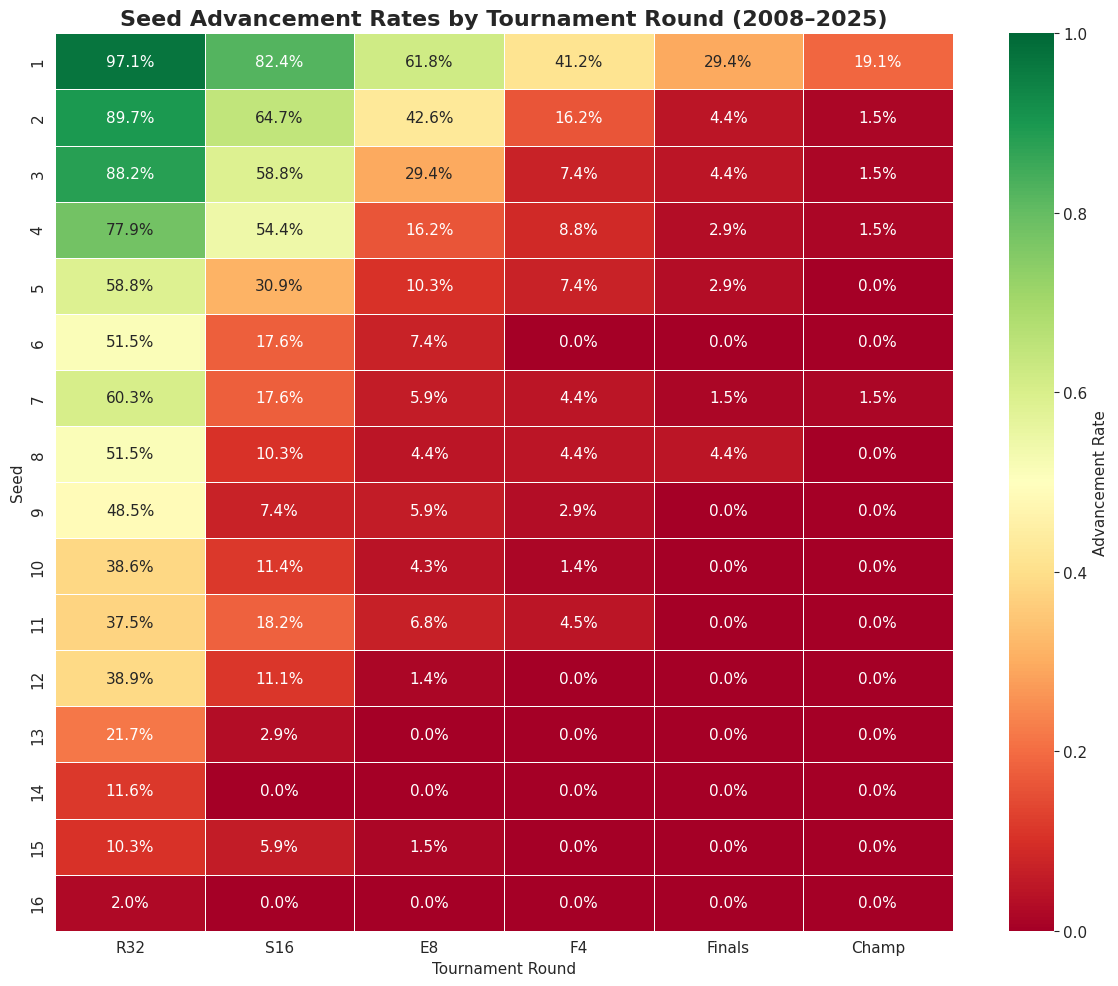

In [ ]:
# ── 2.3  Seed advancement heatmap ────────────────────────────────────
heatmap_rows = []
for seed in range(1, 17):
    s_data = hist[hist['SEED'] == seed]
    total = len(s_data)
    for mins, label in [(1,'R32'),(2,'S16'),(3,'E8'),(4,'F4'),(5,'Finals'),(6,'Champ')]:
        rate = (s_data['WINS'] >= mins).sum() / total if total > 0 else 0
        heatmap_rows.append({'Seed': seed, 'Round': label, 'Rate': rate})

hm = pd.DataFrame(heatmap_rows).pivot(index='Seed', columns='Round', values='Rate')
hm = hm[['R32','S16','E8','F4','Finals','Champ']]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(hm, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Advancement Rate'})
ax.set_title('Seed Advancement Rates by Tournament Round (2008–2025)', fontsize=16, fontweight='bold')
ax.set_ylabel('Seed'); ax.set_xlabel('Tournament Round')
plt.tight_layout(); plt.show()

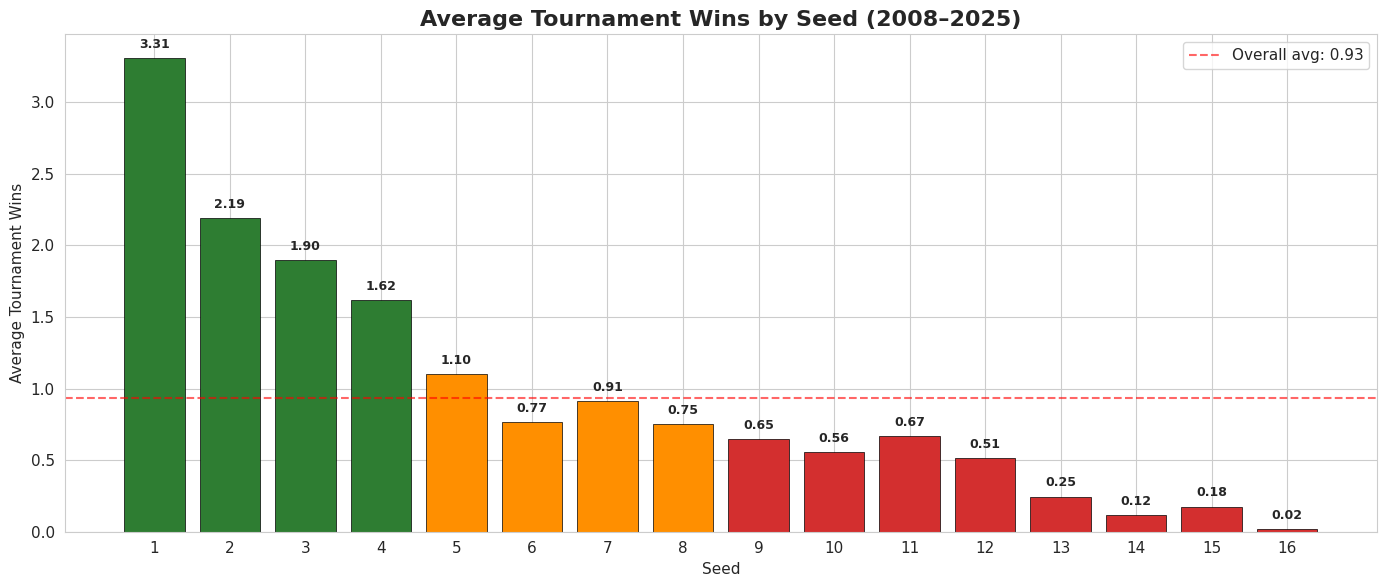

In [ ]:
# ── 2.4  Average wins by seed ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2e7d32' if v >= 1.5 else '#ff8f00' if v >= 0.7 else '#d32f2f' for v in seed_perf['avg_wins']]
ax.bar(range(1,17), seed_perf['avg_wins'], color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(seed_perf['avg_wins']):
    ax.text(i+1, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(y=hist['WINS'].mean(), color='red', linestyle='--', alpha=0.6,
           label=f'Overall avg: {hist["WINS"].mean():.2f}')
ax.set_xlabel('Seed'); ax.set_ylabel('Average Tournament Wins')
ax.set_title('Average Tournament Wins by Seed (2008–2025)', fontsize=16, fontweight='bold')
ax.set_xticks(range(1,17)); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── 2.5  Wins Above Expectation (WAE) ────────────────────────────────
expected_wins_by_seed = hist.groupby('SEED')['WINS'].mean().to_dict()
hist['expected_wins'] = hist['SEED'].map(expected_wins_by_seed)
hist['WAE'] = hist['WINS'] - hist['expected_wins']

team_perf = hist.groupby(['TEAM ID', 'TEAM']).agg(
    appearances=('YEAR','count'), total_WAE=('WAE','sum'), avg_WAE=('WAE','mean'),
    avg_seed=('SEED','mean'), avg_wins=('WINS','mean'), best_finish=('WINS','max'),
).round(3)
team_perf_sig = team_perf[team_perf['appearances'] >= 3].sort_values('total_WAE', ascending=False)

print('🔥 TOP 15 OVER-PERFORMERS')
print('=' * 90)
for _, row in team_perf_sig.head(15).iterrows():
    print(f'{row.name[1]:>25s}: WAE={row["total_WAE"]:+.1f}, Avg Seed={row["avg_seed"]:.1f}, '
          f'Apps={row["appearances"]:.0f}, Best={row["best_finish"]:.0f}W')

print(f'\n❄️  TOP 15 UNDER-PERFORMERS')
print('=' * 90)
for _, row in team_perf_sig.tail(15).sort_values('total_WAE').iterrows():
    print(f'{row.name[1]:>25s}: WAE={row["total_WAE"]:+.1f}, Avg Seed={row["avg_seed"]:.1f}, '
          f'Apps={row["appearances"]:.0f}, Best={row["best_finish"]:.0f}W')

🔥 TOP 15 OVER-PERFORMERS
              Connecticut: WAE=+13.3, Avg Seed=5.3, Apps=11, Best=6W
             Michigan St.: WAE=+10.1, Avg Seed=5.2, Apps=17, Best=5W
                   Butler: WAE=+9.2, Avg Seed=7.1, Apps=9, Best=5W
                 Michigan: WAE=+8.5, Avg Seed=5.7, Apps=12, Best=5W
           North Carolina: WAE=+8.2, Avg Seed=3.7, Apps=15, Best=6W
                  Florida: WAE=+8.1, Avg Seed=5.3, Apps=11, Best=6W
                 Kentucky: WAE=+7.2, Avg Seed=3.8, Apps=14, Best=6W
                   Oregon: WAE=+5.8, Avg Seed=7.5, Apps=10, Best=4W
                     UCLA: WAE=+5.0, Avg Seed=6.1, Apps=12, Best=4W
                 Arkansas: WAE=+4.8, Avg Seed=6.8, Apps=8, Best=3W
                Villanova: WAE=+4.7, Avg Seed=4.2, Apps=13, Best=6W
                  Gonzaga: WAE=+4.6, Avg Seed=4.9, Apps=17, Best=5W
                 Syracuse: WAE=+4.4, Avg Seed=5.5, Apps=10, Best=4W
               Texas Tech: WAE=+4.1, Avg Seed=4.6, Apps=7, Best=5W
           Loyola Chicag

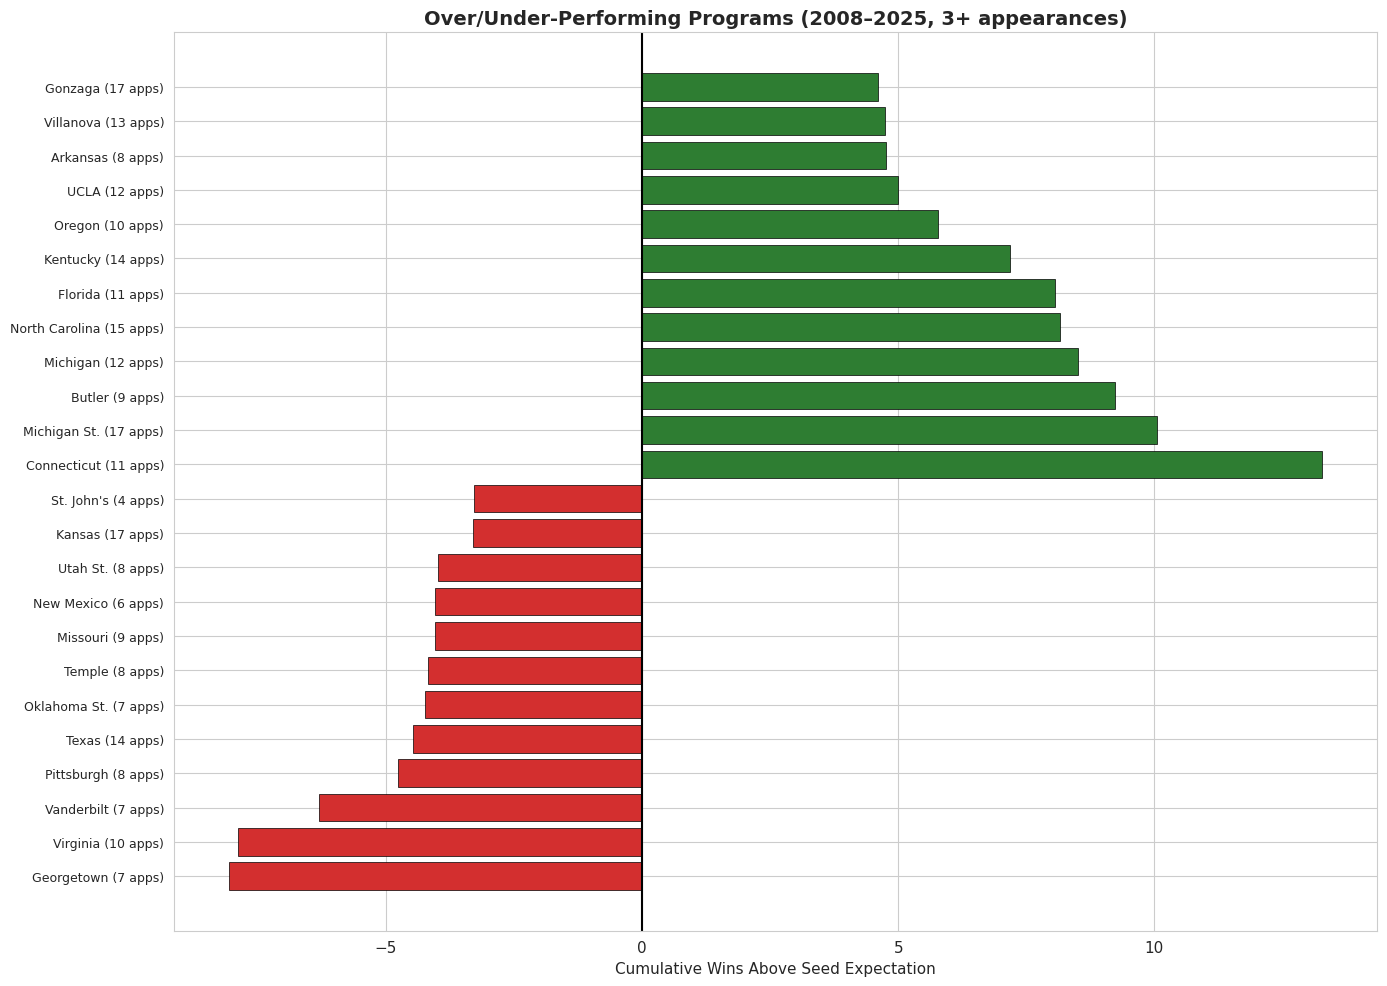

In [ ]:
# ── 2.5b  Visualize over/under-performers ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
n = 12
over = team_perf_sig.head(n).reset_index()
under = team_perf_sig.tail(n).sort_values('total_WAE').reset_index()
combined = pd.concat([under, over]).reset_index(drop=True)
colors = ['#d32f2f' if x < 0 else '#2e7d32' for x in combined['total_WAE']]
ax.barh(range(len(combined)), combined['total_WAE'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels([f"{r['TEAM']} ({r['appearances']:.0f} apps)" for _, r in combined.iterrows()], fontsize=9)
ax.set_xlabel('Cumulative Wins Above Seed Expectation')
ax.set_title('Over/Under-Performing Programs (2008–2025, 3+ appearances)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1.5)
plt.tight_layout(); plt.show()

🏆 Champions by Seed:
  #1: 13x — Florida, Connecticut, Kansas, Baylor, Virginia, Villanova, North Carolina, Duke, Louisville, Kentucky, Duke, North Carolina, Kansas
  #2: 1x — Villanova
  #3: 1x — Connecticut
  #4: 1x — Connecticut
  #7: 1x — Connecticut


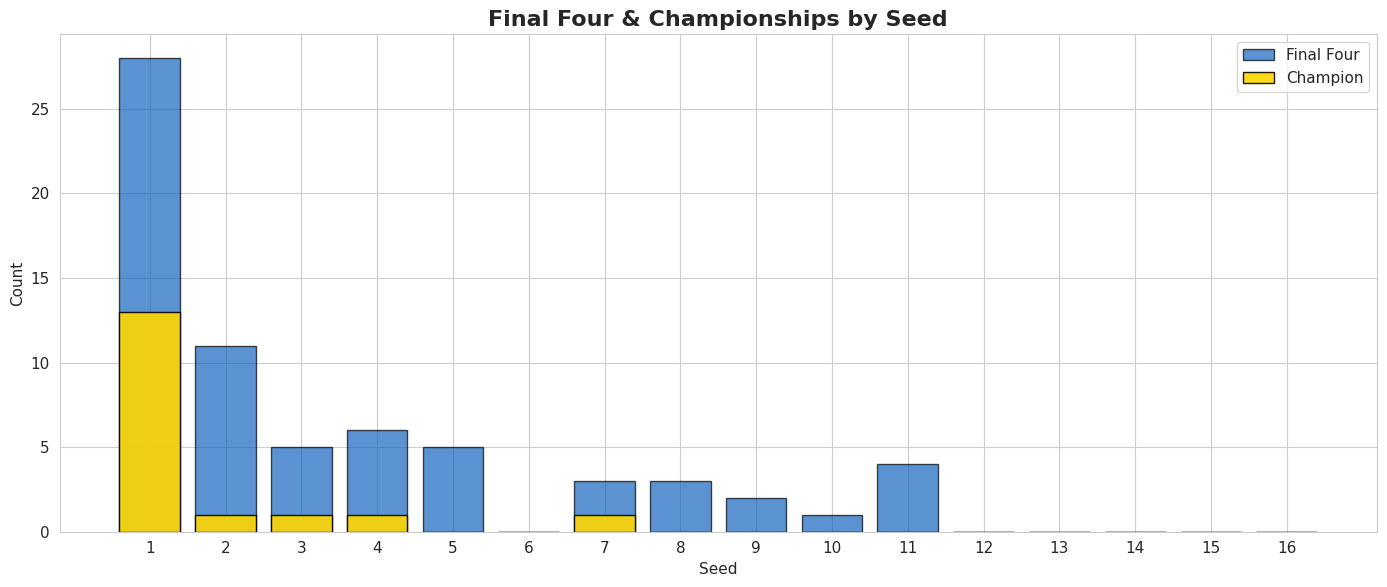

In [ ]:
# ── 2.6  Championship & Final Four distribution ──────────────────────
champions = hist[hist['WINS'] == 6]
print('🏆 Champions by Seed:')
for seed, group in champions.groupby('SEED'):
    print(f'  #{seed}: {len(group)}x — {", ".join(group["TEAM"].tolist())}')

fig, ax = plt.subplots(figsize=(14, 6))
f4c = hist[hist['WINS']>=4].groupby('SEED').size().reindex(range(1,17), fill_value=0)
chc = champions.groupby('SEED').size().reindex(range(1,17), fill_value=0)
ax.bar(range(1,17), f4c, color='#1565C0', alpha=0.7, label='Final Four', edgecolor='black')
ax.bar(range(1,17), chc, color='#FFD600', alpha=0.9, label='Champion', edgecolor='black')
ax.set_xlabel('Seed'); ax.set_ylabel('Count')
ax.set_title('Final Four & Championships by Seed', fontsize=16, fontweight='bold')
ax.set_xticks(range(1,17)); ax.legend()
plt.tight_layout(); plt.show()

---

# Phase 3 — Feature engineering & importance

**Answers Question 2:** What attributes drive tournament success?

We select 24 statistical features, engineer 4 new ones, and merge 7 resume metrics.

> **Note:** SEED is included in Phase 3 for correlation/importance analysis
> (it's informative to see how predictive it is), but will be **removed** in Phase 4
> before model training. We want our model to learn from actual basketball performance,
> not from the committee's ranking.

In [ ]:
# ── 3.1  Statistical features ────────────────────────────────────────
stat_features = [
    'SEED',  # included here for analysis, REMOVED in Phase 4
    'KADJ EM', 'KADJ O', 'KADJ D', 'KADJ T',
    'BADJ EM', 'BADJ O', 'BADJ D', 'BARTHAG',
    'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%', 'TOV%D',
    'OREB%', 'DREB%', 'WIN%',
    'TALENT', 'EXP', 'AVG HGT', 'EFF HGT',
    'WAB', 'ELITE SOS',
]
print(f'{len(stat_features)} statistical features selected')

24 statistical features selected


In [ ]:
# ── 3.2  Engineered features ─────────────────────────────────────────
conf_hist_wins = hist.groupby('CONF')['WINS'].mean().to_dict()
hist['conf_avg_wins'] = hist['CONF'].map(conf_hist_wins)

print('Conference strength (top 10):')
for c, v in sorted(conf_hist_wins.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'  {c:>5s}: {v:.3f}')

print('\nCalculating prior tournament experience...')
prior_records = []
for _, row in hist.iterrows():
    prior = hist[(hist['TEAM ID'] == row['TEAM ID']) & (hist['YEAR'] < row['YEAR'])]
    prior_records.append({
        'TEAM NO': row['TEAM NO'],
        'prior_appearances': len(prior),
        'prior_avg_wins': prior['WINS'].mean() if len(prior) > 0 else 0,
        'prior_best': prior['WINS'].max() if len(prior) > 0 else 0,
    })
hist = hist.merge(pd.DataFrame(prior_records), on='TEAM NO', how='left')
eng_features = ['conf_avg_wins', 'prior_appearances', 'prior_avg_wins', 'prior_best']
print('✅ 4 engineered features created')

Conference strength (top 10):
    ACC: 1.600
    B10: 1.383
    B12: 1.382
    SEC: 1.367
     BE: 1.349
    WCC: 1.273
    P12: 1.240
    P10: 1.222
    MVC: 1.000
   SInd: 1.000

Calculating prior tournament experience...
✅ 4 engineered features created


In [ ]:
# ── 3.3  Resume features ─────────────────────────────────────────────
resume_features = ['NET RPI', 'WAB RANK', 'ELO', 'B POWER', 'Q1 W', 'Q1 PLUS Q2 W', 'R SCORE']
merge_cols = ['TEAM NO'] + [c for c in resume_features if c in resumes.columns]
hist = hist.merge(resumes[merge_cols], on='TEAM NO', how='left')
available_resume = [c for c in resume_features if c in hist.columns]
print(f'Resume features merged: {available_resume}')

Resume features merged: ['NET RPI', 'WAB RANK', 'ELO', 'B POWER', 'Q1 W', 'Q1 PLUS Q2 W', 'R SCORE']


In [ ]:
# ── 3.4  Full feature matrix (WITH SEED for analysis) ────────────────
ALL_FEATURES_WITH_SEED = stat_features + eng_features + available_resume
ALL_FEATURES_WITH_SEED = [f for f in ALL_FEATURES_WITH_SEED if f in hist.columns]

X_all = hist[ALL_FEATURES_WITH_SEED].copy()
y = hist['WINS'].copy()
valid = X_all.notnull().all(axis=1) & y.notnull()
X_clean_all = X_all[valid]
y_clean = y[valid]
years = hist.loc[valid, 'YEAR']

print(f'Full feature set (with SEED): {len(ALL_FEATURES_WITH_SEED)} features, {len(X_clean_all)} rows')
print(f'\nFeatures:')
for i, f in enumerate(ALL_FEATURES_WITH_SEED):
    tag = ' ← REMOVED in Phase 4' if f == 'SEED' else ''
    print(f'  {i+1:>2d}. {f}{tag}')

Full feature set (with SEED): 35 features, 1147 rows

Features:
   1. SEED ← REMOVED in Phase 4
   2. KADJ EM
   3. KADJ O
   4. KADJ D
   5. KADJ T
   6. BADJ EM
   7. BADJ O
   8. BADJ D
   9. BARTHAG
  10. EFG%
  11. EFG%D
  12. FTR
  13. FTRD
  14. TOV%
  15. TOV%D
  16. OREB%
  17. DREB%
  18. WIN%
  19. TALENT
  20. EXP
  21. AVG HGT
  22. EFF HGT
  23. WAB
  24. ELITE SOS
  25. conf_avg_wins
  26. prior_appearances
  27. prior_avg_wins
  28. prior_best
  29. NET RPI
  30. WAB RANK
  31. ELO
  32. B POWER
  33. Q1 W
  34. Q1 PLUS Q2 W
  35. R SCORE


Feature Importance (Random Forest — includes SEED for reference):
                 BADJ EM: 0.0507  ██████████
                 KADJ EM: 0.0464  █████████
                 BARTHAG: 0.0462  █████████
                 B POWER: 0.0434  ████████
                     WAB: 0.0425  ████████
                 R SCORE: 0.0424  ████████
                WAB RANK: 0.0403  ████████
                    SEED: 0.0374  ███████ ◄ removed in model
                 NET RPI: 0.0352  ███████
                  TALENT: 0.0325  ██████
                     ELO: 0.0317  ██████
                 EFF HGT: 0.0294  █████
                 AVG HGT: 0.0273  █████
               ELITE SOS: 0.0271  █████
                   OREB%: 0.0266  █████
                    FTRD: 0.0262  █████
                  KADJ D: 0.0259  █████
                  BADJ D: 0.0256  █████
                  KADJ O: 0.0250  █████
                     EXP: 0.0248  ████
                   TOV%D: 0.0245  ████
                     FTR: 0.0245  ████
       

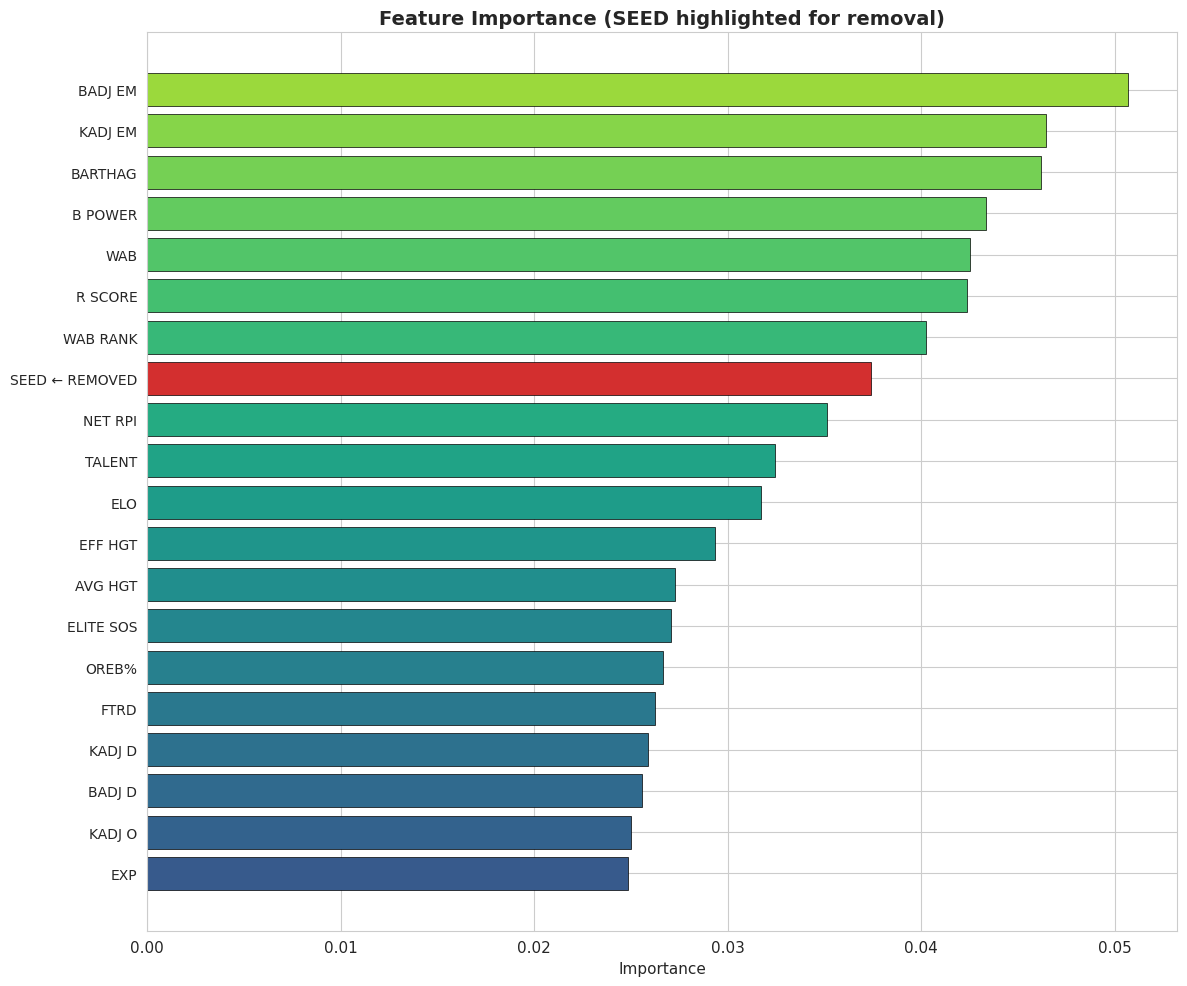

In [ ]:
# ── 3.5  Feature importance (Random Forest, WITH SEED) ───────────────
y_binned = y_clean.clip(upper=4).astype(int)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_clean_all, y_binned)

rf_imp = pd.Series(rf.feature_importances_, index=ALL_FEATURES_WITH_SEED).sort_values(ascending=False)

print('Feature Importance (Random Forest — includes SEED for reference):')
print('=' * 65)
for feat, imp in rf_imp.items():
    marker = ' ◄ removed in model' if feat == 'SEED' else ''
    bar = '█' * int(imp * 200)
    print(f'  {feat:>22s}: {imp:.4f}  {bar}{marker}')

fig, ax = plt.subplots(figsize=(12, 10))
top20 = rf_imp.head(20)
colors_imp = ['#d32f2f' if f == 'SEED' else plt.cm.viridis(0.85 - i*0.03) for i, f in enumerate(top20.index)]
ax.barh(range(len(top20)), top20.values, color=colors_imp, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top20)))
labels = [f'{f} ← REMOVED' if f == 'SEED' else f for f in top20.index]
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Importance'); ax.set_title('Feature Importance (SEED highlighted for removal)', fontsize=14, fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

Correlations with Tournament Wins:
                     WAB: +0.556
                 BADJ EM: +0.551
                 KADJ EM: +0.548
            Q1 PLUS Q2 W: +0.522
                    Q1 W: +0.508
                  BADJ O: +0.462
                  KADJ O: +0.457
                 R SCORE: +0.450
                  TALENT: +0.447
                 BARTHAG: +0.443
           conf_avg_wins: +0.413
               ELITE SOS: +0.408
              prior_best: +0.398
          prior_avg_wins: +0.391
                    WIN%: +0.375
       prior_appearances: +0.282
                 AVG HGT: +0.256
                 EFF HGT: +0.236
                   OREB%: +0.218
                    EFG%: +0.185
                   DREB%: +0.045
                   TOV%D: +0.041
                  KADJ T: +0.001
                     FTR: -0.068
                     EXP: -0.134
                    FTRD: -0.145
                    TOV%: -0.169
                   EFG%D: -0.221
                  BADJ D: -0.406
        

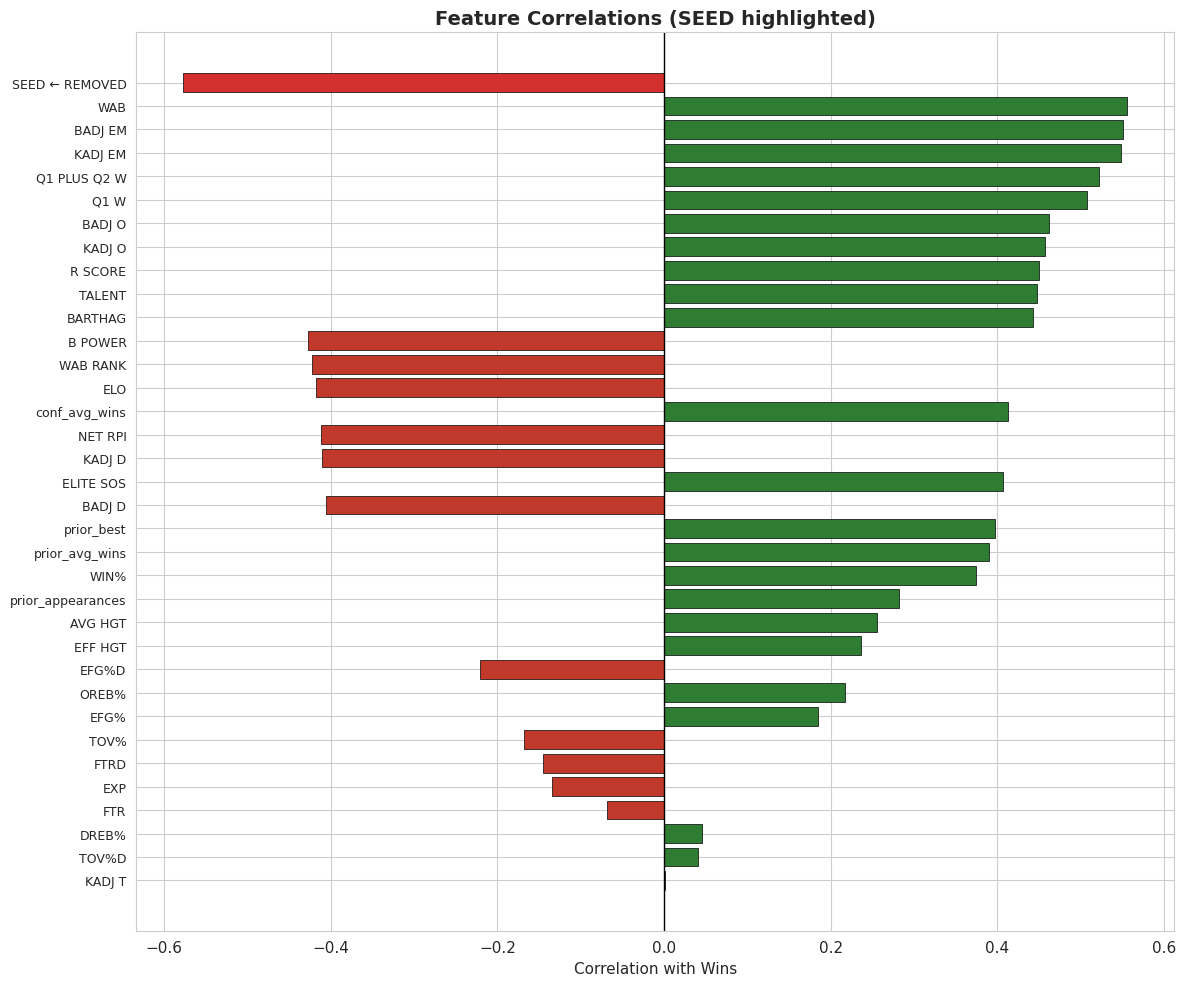

In [ ]:
# ── 3.6  Correlation analysis ────────────────────────────────────────
correlations = X_clean_all.corrwith(y_clean).sort_values(ascending=False)
print('Correlations with Tournament Wins:')
for feat, corr in correlations.items():
    marker = ' ◄ removed in model' if feat == 'SEED' else ''
    print(f'  {feat:>22s}: {corr:+.3f}{marker}')

fig, ax = plt.subplots(figsize=(12, 10))
sc = correlations.reindex(correlations.abs().sort_values(ascending=True).index)
colors_c = ['#d32f2f' if f == 'SEED' else ('#2e7d32' if v > 0 else '#c0392b') for f, v in sc.items()]
ax.barh(range(len(sc)), sc.values, color=colors_c, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(sc)))
ax.set_yticklabels([f'{f} ← REMOVED' if f == 'SEED' else f for f in sc.index], fontsize=9)
ax.set_xlabel('Correlation with Wins'); ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Feature Correlations (SEED highlighted)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Phase 3 observations

SEED has the strongest absolute correlation with wins (r = −0.58), which makes sense —
it's the committee's expert ranking. But in Phase 4, we **deliberately remove it** to test
whether the model can learn to predict success from performance stats alone.

---

# Phase 4 — Model building & validation (SEED REMOVED)

## Key change: SEED is dropped from the feature set

**Why remove SEED?** SEED is a human judgment call by the selection committee. By removing it,
we force the model to learn entirely from measurable basketball performance — efficiency,
résumé, talent, experience, and conference strength. This tests whether the data itself,
without the committee's opinion, can predict tournament outcomes.

**Model:** Gradient Boosting Regressor (300 trees, depth 4, learning rate 0.1)

**Validation:** Leave-One-Year-Out cross-validation (train on 17 years, predict the 1 left out,
repeat 18 times)

In [ ]:
# ── 4.1  Remove SEED and prepare feature matrix ──────────────────────

# Create the model feature set WITHOUT SEED
MODEL_FEATURES = [f for f in ALL_FEATURES_WITH_SEED if f != 'SEED']

print(f'Features WITH SEED:    {len(ALL_FEATURES_WITH_SEED)}')
print(f'Features WITHOUT SEED: {len(MODEL_FEATURES)}')
print(f'\nRemoved: SEED')
print(f'\nModel features ({len(MODEL_FEATURES)}):')
for i, f in enumerate(MODEL_FEATURES):
    print(f'  {i+1:>2d}. {f}')

# Build X without SEED
X_clean = X_clean_all[MODEL_FEATURES].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f'\nFeature matrix: {X_scaled.shape[0]} rows × {X_scaled.shape[1]} features (no SEED)')

Features WITH SEED:    35
Features WITHOUT SEED: 34

Removed: SEED

Model features (34):
   1. KADJ EM
   2. KADJ O
   3. KADJ D
   4. KADJ T
   5. BADJ EM
   6. BADJ O
   7. BADJ D
   8. BARTHAG
   9. EFG%
  10. EFG%D
  11. FTR
  12. FTRD
  13. TOV%
  14. TOV%D
  15. OREB%
  16. DREB%
  17. WIN%
  18. TALENT
  19. EXP
  20. AVG HGT
  21. EFF HGT
  22. WAB
  23. ELITE SOS
  24. conf_avg_wins
  25. prior_appearances
  26. prior_avg_wins
  27. prior_best
  28. NET RPI
  29. WAB RANK
  30. ELO
  31. B POWER
  32. Q1 W
  33. Q1 PLUS Q2 W
  34. R SCORE

Feature matrix: 1147 rows × 34 features (no SEED)


In [ ]:
# ── 4.2  Leave-One-Year-Out cross-validation ─────────────────────────
logo = LeaveOneGroupOut()
gb_params = dict(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

year_results = []
print('LEAVE-ONE-YEAR-OUT CROSS-VALIDATION (no SEED in features)')
print('=' * 65)
print(f'{"Year":>6s} {"MAE":>8s} {"R²":>8s} {"Teams":>6s} {"Quality":>18s}')
print('-' * 65)

for train_idx, test_idx in logo.split(X_scaled, y_clean, years):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y_clean.iloc[train_idx], y_clean.iloc[test_idx]
    yr = years.iloc[test_idx].iloc[0]
    gb = GradientBoostingRegressor(**gb_params)
    gb.fit(X_tr, y_tr)
    y_pred = gb.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    quality = '✅ Good' if r2 > 0.4 else '⚠️ Moderate' if r2 > 0.2 else '❌ Upset year'
    year_results.append({'year': yr, 'mae': mae, 'r2': r2})
    print(f'{yr:>6d} {mae:>8.3f} {r2:>8.3f} {len(y_te):>6d} {quality:>18s}')

yr_df = pd.DataFrame(year_results)
print('-' * 65)
print(f'{"MEAN":>6s} {yr_df["mae"].mean():>8.3f} {yr_df["r2"].mean():>8.3f}')

LEAVE-ONE-YEAR-OUT CROSS-VALIDATION (no SEED in features)
  Year      MAE       R²  Teams            Quality
-----------------------------------------------------------------
  2008    0.729    0.415     65             ✅ Good
  2009    0.696    0.506     65             ✅ Good
  2010    0.803    0.186     65       ❌ Upset year
  2011    0.852    0.037     68       ❌ Upset year
  2012    0.697    0.482     68             ✅ Good
  2013    0.897    0.132     68       ❌ Upset year
  2014    0.827    0.084     68       ❌ Upset year
  2015    0.711    0.434     68             ✅ Good
  2016    0.746    0.388     68        ⚠️ Moderate
  2017    0.680    0.337     68        ⚠️ Moderate
  2018    0.850    0.151     68       ❌ Upset year
  2019    0.639    0.533     68             ✅ Good
  2021    0.867    0.239     68        ⚠️ Moderate
  2022    0.784    0.297     68        ⚠️ Moderate
  2023    0.827    0.154     68       ❌ Upset year
  2024    0.686    0.400     68             ✅ Good
  2025   

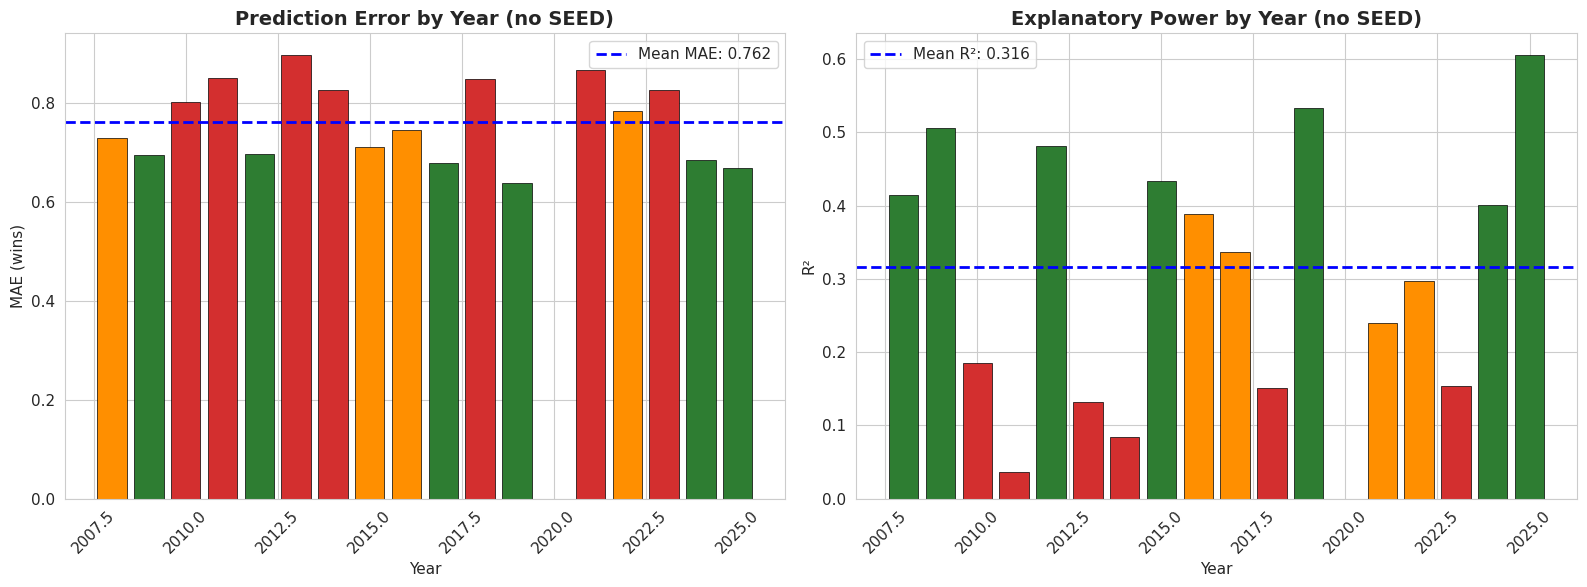

In [ ]:
# ── 4.2b  Visualize model performance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
c = ['#d32f2f' if v > 0.8 else '#ff8f00' if v > 0.7 else '#2e7d32' for v in yr_df['mae']]
ax.bar(yr_df['year'], yr_df['mae'], color=c, edgecolor='black', linewidth=0.5)
ax.axhline(y=yr_df['mae'].mean(), color='blue', linestyle='--',
           label=f'Mean MAE: {yr_df["mae"].mean():.3f}', linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('MAE (wins)')
ax.set_title('Prediction Error by Year (no SEED)', fontsize=14, fontweight='bold')
ax.legend(); ax.tick_params(axis='x', rotation=45)

ax = axes[1]
c2 = ['#2e7d32' if v > 0.4 else '#ff8f00' if v > 0.2 else '#d32f2f' for v in yr_df['r2']]
ax.bar(yr_df['year'], yr_df['r2'], color=c2, edgecolor='black', linewidth=0.5)
ax.axhline(y=yr_df['r2'].mean(), color='blue', linestyle='--',
           label=f'Mean R²: {yr_df["r2"].mean():.3f}', linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('R²')
ax.set_title('Explanatory Power by Year (no SEED)', fontsize=14, fontweight='bold')
ax.legend(); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

FINAL MODEL — Feature Importance (no SEED)
                 R SCORE: 0.2402  ████████████████████████████████████████████████
                     WAB: 0.0814  ████████████████
                 BARTHAG: 0.0559  ███████████
                WAB RANK: 0.0360  ███████
                 BADJ EM: 0.0341  ██████
                     FTR: 0.0337  ██████
                 B POWER: 0.0330  ██████
                   OREB%: 0.0312  ██████
                   DREB%: 0.0291  █████
                  TALENT: 0.0282  █████
                    FTRD: 0.0256  █████
               ELITE SOS: 0.0247  ████
                     EXP: 0.0242  ████
                  KADJ T: 0.0241  ████
                     ELO: 0.0239  ████


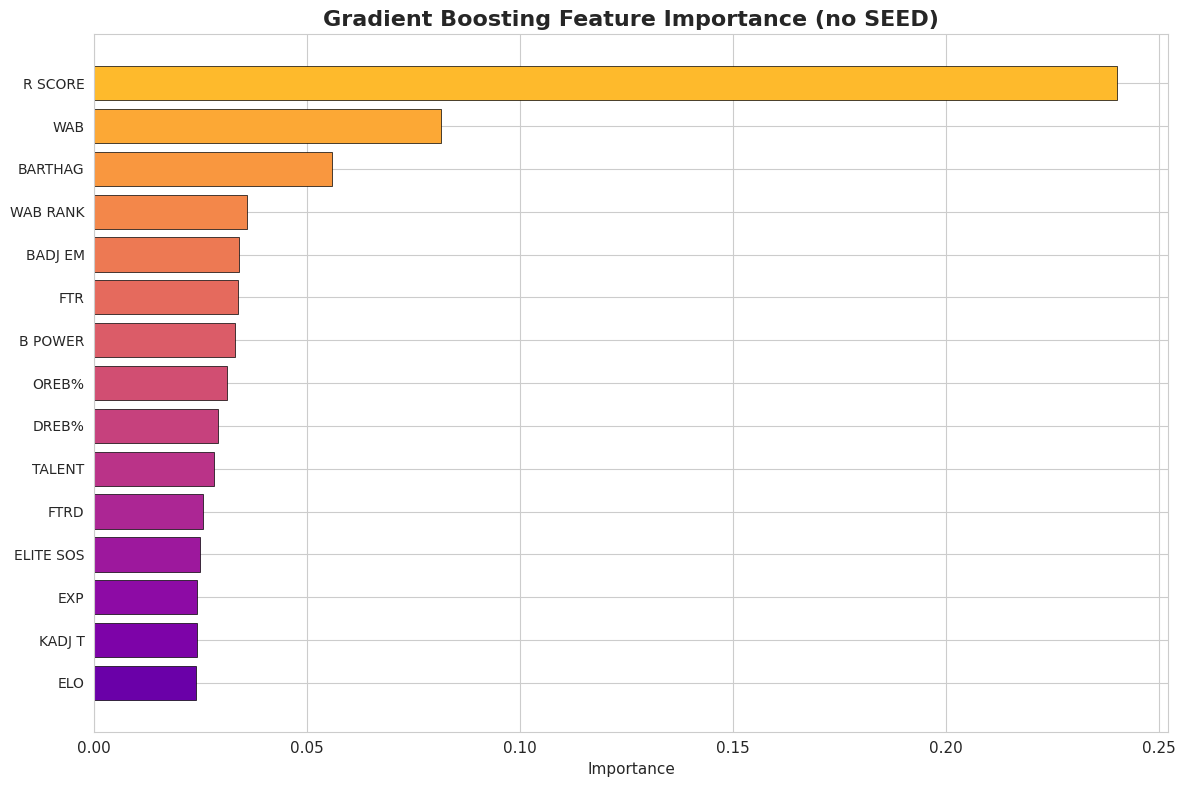


✅ Final model trained on 1147 rows with 34 features (SEED excluded)


In [ ]:
# ── 4.3  Train final model on ALL historical data ────────────────────
gb_final = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
gb_final.fit(X_scaled, y_clean)

gb_imp = pd.Series(gb_final.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)

print('FINAL MODEL — Feature Importance (no SEED)')
print('=' * 65)
for feat, imp in gb_imp.head(15).items():
    bar = '█' * int(imp * 200)
    print(f'  {feat:>22s}: {imp:.4f}  {bar}')

fig, ax = plt.subplots(figsize=(12, 8))
top15 = gb_imp.head(15)
ax.barh(range(len(top15)), top15.values, color=plt.cm.plasma(np.linspace(0.85,0.2,len(top15))),
        edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15.index, fontsize=10)
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting Feature Importance (no SEED)', fontsize=16, fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

print(f'\n✅ Final model trained on {len(X_scaled)} rows with {len(MODEL_FEATURES)} features (SEED excluded)')

---

# Phase 5 — 2026 predictions (16 live teams only)

## Key change: Predictions only for teams still alive

Instead of predicting all 68 teams, we focus on the **16 teams still in the tournament**:

| | | | |
|---|---|---|---|
| Duke | Arizona | Michigan | Connecticut |
| Purdue | Iowa St. | Houston | Michigan St. |
| Illinois | Arkansas | Alabama | Nebraska |
| St. John's | Tennessee | Iowa | Texas |

The model uses the same pipeline as historical data: engineer features, apply the
**same scaler** (not refit), and predict with the trained model — all **without SEED**.

In [ ]:
# ── 5.1  Define the 16 live teams ────────────────────────────────────

# Exact names as they appear in the dataset
LIVE_TEAMS = [
    'Duke', 'Arizona', 'Michigan', 'Connecticut',
    'Purdue', 'Iowa St.', 'Houston', 'Michigan St.',
    'Illinois', 'Arkansas', 'Alabama', 'Nebraska',
    "St. John's", 'Tennessee', 'Iowa', 'Texas',
]

print(f'Live teams to predict: {len(LIVE_TEAMS)}')
for t in LIVE_TEAMS:
    print(f'  {t}')

Live teams to predict: 16
  Duke
  Arizona
  Michigan
  Connecticut
  Purdue
  Iowa St.
  Houston
  Michigan St.
  Illinois
  Arkansas
  Alabama
  Nebraska
  St. John's
  Tennessee
  Iowa
  Texas


In [ ]:
# ── 5.2  Prepare 2026 features for live teams ────────────────────────

# Start with all 2026 data, then filter to live teams
kp26 = kenpom[kenpom['YEAR'] == 2026].copy()

# A. Conference strength
kp26['conf_avg_wins'] = kp26['CONF'].map(conf_hist_wins).fillna(0)

# B. Prior tournament experience
prior_2026 = []
for _, row in kp26.iterrows():
    prior = hist[hist['TEAM ID'] == row['TEAM ID']]
    prior_2026.append({
        'TEAM NO': row['TEAM NO'],
        'prior_appearances': len(prior),
        'prior_avg_wins': prior['WINS'].mean() if len(prior) > 0 else 0,
        'prior_best': prior['WINS'].max() if len(prior) > 0 else 0,
    })
kp26 = kp26.merge(pd.DataFrame(prior_2026), on='TEAM NO', how='left')

# C. Resume data
kp26 = kp26.merge(resumes[merge_cols], on='TEAM NO', how='left')

# D. Fill missing
for f in MODEL_FEATURES:
    if f not in kp26.columns:
        kp26[f] = 0
    kp26[f] = kp26[f].fillna(0)

# E. Filter to LIVE TEAMS ONLY
kp26_live = kp26[kp26['TEAM'].isin(LIVE_TEAMS)].copy()

print(f'2026 teams prepared: {len(kp26)} total, {len(kp26_live)} live teams')
print(f'\nLive teams found in data:')
for _, row in kp26_live.sort_values('SEED').iterrows():
    print(f'  #{int(row["SEED"]):>2d}  {row["TEAM"]}')

# Check if all 16 were found
found = set(kp26_live['TEAM'].tolist())
missing = set(LIVE_TEAMS) - found
if missing:
    print(f'\n⚠️ NOT FOUND in data: {missing}')
else:
    print(f'\n✅ All 16 teams found!')

2026 teams prepared: 68 total, 16 live teams

Live teams found in data:
  # 1  Arizona
  # 1  Duke
  # 1  Michigan
  # 2  Houston
  # 2  Iowa St.
  # 2  Purdue
  # 2  Connecticut
  # 3  Illinois
  # 3  Michigan St.
  # 4  Nebraska
  # 4  Alabama
  # 4  Arkansas
  # 5  St. John's
  # 6  Tennessee
  # 9  Iowa
  #11  Texas

✅ All 16 teams found!


In [ ]:
# ── 5.3  Generate predictions (no SEED) ──────────────────────────────

# Extract features in SAME order as training, WITHOUT SEED
X_live = kp26_live[MODEL_FEATURES].values

# Use the SAME scaler (transform, not fit_transform)
X_live_scaled = scaler.transform(X_live)

# Predict
kp26_live['predicted_wins'] = gb_final.predict(X_live_scaled)

# Sort by predicted performance
kp26_live = kp26_live.sort_values('predicted_wins', ascending=False)

# Display
print('🏀 2026 PREDICTIONS — 16 LIVE TEAMS (model trained WITHOUT SEED)')
print('=' * 100)
print(f'{"Rank":>4s} {"Team":>22s} {"Seed":>5s} {"Conf":>5s} {"Pred Wins":>10s} '
      f'{"KADJ EM":>8s} {"BARTHAG":>8s} {"Talent":>7s} {"R SCORE":>8s}')
print('-' * 100)
for i, (_, row) in enumerate(kp26_live.iterrows()):
    print(f'{i+1:>4d} {row["TEAM"]:>22s}  #{int(row["SEED"]):>2d}  {row["CONF"]:>5s} '
          f'{row["predicted_wins"]:>10.2f} {row["KADJ EM"]:>8.1f} {row["BARTHAG"]:>8.3f} '
          f'{row["TALENT"]:>7.1f} {row["R SCORE"]:>8.2f}')

🏀 2026 PREDICTIONS — 16 LIVE TEAMS (model trained WITHOUT SEED)
Rank                   Team  Seed  Conf  Pred Wins  KADJ EM  BARTHAG  Talent  R SCORE
----------------------------------------------------------------------------------------------------
   1               Michigan  # 1    B10       5.29     37.6    0.980    69.9    99.98
   2                   Duke  # 1    ACC       4.91     38.9    0.981    91.2    99.98
   3               Illinois  # 3    B10       4.41     32.1    0.968    63.1    99.75
   4                Arizona  # 1    B12       4.26     37.7    0.978    73.5    99.98
   5                 Purdue  # 2    B10       3.54     31.2    0.964    59.3    99.89
   6                Houston  # 2    B12       3.49     33.4    0.971    82.0    99.90
   7               Iowa St.  # 2    B12       3.30     32.4    0.966    50.5    99.86
   8            Connecticut  # 2     BE       2.86     27.9    0.952    84.3    99.80
   9                Alabama  # 4    SEC       2.13     25.7  

In [ ]:
# ── 5.4  Identify the predicted Final Four & Champion ─────────────────

# Pick best predicted team from each region (QUAD ID)
region_names = {1: 'East', 2: 'West', 3: 'South', 4: 'Midwest'}
final_four = []

print('🏆 REGIONAL ANALYSIS (live teams only, no SEED in model)')
print('=' * 80)

for qid in sorted(kp26_live['QUAD ID'].unique()):
    region = kp26_live[kp26_live['QUAD ID'] == qid].sort_values('predicted_wins', ascending=False)
    winner = region.iloc[0]
    final_four.append(winner)
    rname = region_names.get(qid, f'Region {qid}')
    print(f'\n📍 {rname} Region:')
    print(f'   WINNER → {winner["TEAM"]} (#{int(winner["SEED"])}) — {winner["predicted_wins"]:.2f} predicted wins')
    if len(region) > 1:
        print(f'   All live teams in region:')
        for j, (_, r) in enumerate(region.iterrows()):
            marker = '  ★' if j == 0 else '   '
            print(f'   {marker} {r["TEAM"]} (#{int(r["SEED"])}) — {r["predicted_wins"]:.2f}')

f4_df = pd.DataFrame(final_four).sort_values('predicted_wins', ascending=False)
champion = f4_df.iloc[0]
runner_up = f4_df.iloc[1]

print(f'\n{"="*80}')
print(f'🏆 PREDICTED FINAL FOUR:')
for _, row in f4_df.iterrows():
    print(f'  {row["TEAM"]:>20s}  (#{int(row["SEED"])})  —  {row["predicted_wins"]:.2f} predicted wins')
print(f'\n🥇 CHAMPION:   {champion["TEAM"]} (#{int(champion["SEED"])})')
print(f'🥈 RUNNER-UP:  {runner_up["TEAM"]} (#{int(runner_up["SEED"])})')

🏆 REGIONAL ANALYSIS (live teams only, no SEED in model)

📍 East Region:
   WINNER → Michigan (#1) — 5.29 predicted wins
   All live teams in region:
     ★ Michigan (#1) — 5.29
       Iowa St. (#2) — 3.30
       Alabama (#4) — 2.13
       Tennessee (#6) — 0.75

📍 West Region:
   WINNER → Arizona (#1) — 4.26 predicted wins
   All live teams in region:
     ★ Arizona (#1) — 4.26
       Purdue (#2) — 3.54
       Arkansas (#4) — 2.09
       Texas (#11) — 0.67

📍 South Region:
   WINNER → Illinois (#3) — 4.41 predicted wins
   All live teams in region:
     ★ Illinois (#3) — 4.41
       Houston (#2) — 3.49
       Nebraska (#4) — 1.96
       Iowa (#9) — 0.42

📍 Midwest Region:
   WINNER → Duke (#1) — 4.91 predicted wins
   All live teams in region:
     ★ Duke (#1) — 4.91
       Connecticut (#2) — 2.86
       St. John's (#5) — 1.63
       Michigan St. (#3) — 1.51

🏆 PREDICTED FINAL FOUR:
              Michigan  (#1)  —  5.29 predicted wins
                  Duke  (#1)  —  4.91 predicted wins

In [ ]:
# ── 5.5  Upset watch ─────────────────────────────────────────────────
kp26_live['expected_wins'] = kp26_live['SEED'].map(expected_wins_by_seed)
kp26_live['wins_above_expected'] = kp26_live['predicted_wins'] - kp26_live['expected_wins']

# Sort all 16 by WAE to see who's projected above/below their seed
wae_sorted = kp26_live.sort_values('wins_above_expected', ascending=False)

print('🔥 ALL 16 LIVE TEAMS — Predicted Wins vs Seed Expectation')
print('=' * 85)
print(f'{"Seed":>5s} {"Team":>22s} {"Pred Wins":>10s} {"Seed Avg":>9s} {"Diff":>8s}')
print('-' * 85)
for _, row in wae_sorted.iterrows():
    diff = row['wins_above_expected']
    marker = ' 🔥' if diff > 0.3 else ' ❄️' if diff < -0.3 else ''
    print(f'#{int(row["SEED"]):>3d}  {row["TEAM"]:>22s} {row["predicted_wins"]:>10.2f} '
          f'{row["expected_wins"]:>9.2f} {diff:>+8.2f}{marker}')

🔥 ALL 16 LIVE TEAMS — Predicted Wins vs Seed Expectation
 Seed                   Team  Pred Wins  Seed Avg     Diff
-------------------------------------------------------------------------------------
#  3                Illinois       4.41      1.90    +2.51 🔥
#  1                Michigan       5.29      3.31    +1.98 🔥
#  1                    Duke       4.91      3.31    +1.60 🔥
#  2                  Purdue       3.54      2.19    +1.35 🔥
#  2                 Houston       3.49      2.19    +1.29 🔥
#  2                Iowa St.       3.30      2.19    +1.11 🔥
#  1                 Arizona       4.26      3.31    +0.95 🔥
#  2             Connecticut       2.86      2.19    +0.67 🔥
#  5              St. John's       1.63      1.10    +0.52 🔥
#  4                 Alabama       2.13      1.62    +0.51 🔥
#  4                Arkansas       2.09      1.62    +0.47 🔥
#  4                Nebraska       1.96      1.62    +0.34 🔥
# 11                   Texas       0.67      0.67    -0.00
#  6   

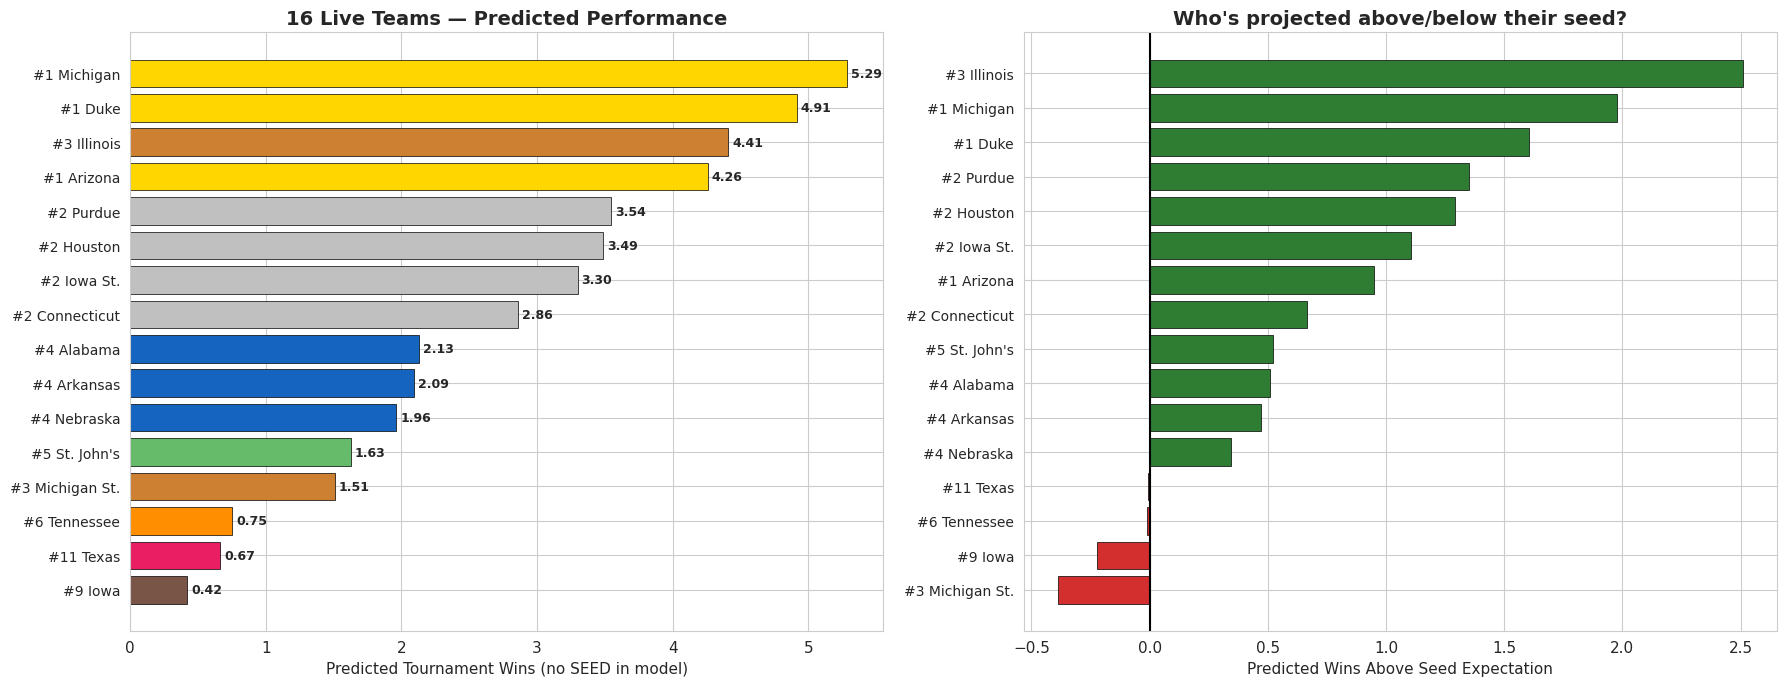

In [ ]:
# ── 5.6  Final visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: All 16 teams ranked by predicted wins
ax = axes[0]
display = kp26_live.sort_values('predicted_wins', ascending=True)  # ascending for horizontal bar
seed_colors = {1:'#FFD600', 2:'#C0C0C0', 3:'#CD7F32', 4:'#1565C0', 5:'#66bb6a',
               6:'#ff8f00', 7:'#9C27B0', 8:'#00BCD4', 9:'#795548', 10:'#607D8B', 11:'#E91E63'}
colors_bar = [seed_colors.get(int(s), '#888888') for s in display['SEED']]
ax.barh(range(len(display)), display['predicted_wins'], color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(display)))
ax.set_yticklabels([f"#{int(r['SEED'])} {r['TEAM']}" for _, r in display.iterrows()], fontsize=10)
ax.set_xlabel('Predicted Tournament Wins (no SEED in model)')
ax.set_title('16 Live Teams — Predicted Performance', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(display.iterrows()):
    ax.text(row['predicted_wins'] + 0.03, i, f'{row["predicted_wins"]:.2f}', va='center', fontsize=9, fontweight='bold')

# Chart 2: WAE for live teams
ax = axes[1]
wae_display = wae_sorted.sort_values('wins_above_expected', ascending=True)
wae_colors = ['#2e7d32' if v > 0 else '#d32f2f' for v in wae_display['wins_above_expected']]
ax.barh(range(len(wae_display)), wae_display['wins_above_expected'], color=wae_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(wae_display)))
ax.set_yticklabels([f"#{int(r['SEED'])} {r['TEAM']}" for _, r in wae_display.iterrows()], fontsize=10)
ax.set_xlabel('Predicted Wins Above Seed Expectation')
ax.set_title('Who\'s projected above/below their seed?', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1.5)

plt.tight_layout(); plt.show()

### ✅ Phase 5 complete

**Key differences from v3:**
- Model trained **without SEED** — predictions come purely from performance metrics
- Predictions narrowed to **16 live teams** still in the tournament
- Regional winners selected only from surviving teams

---

## Appendix — Export

In [ ]:
# Export predictions
export_cols = ['TEAM', 'SEED', 'CONF', 'QUAD ID', 'predicted_wins', 'expected_wins',
               'wins_above_expected', 'KADJ EM', 'BARTHAG', 'R SCORE', 'TALENT',
               'prior_appearances', 'prior_avg_wins']
kp26_live[export_cols].sort_values('predicted_wins', ascending=False).to_csv(
    'predictions_2026_live_16_no_seed.csv', index=False)
print('✅ Predictions → predictions_2026_live_16_no_seed.csv')

seed_perf.to_csv('seed_performance_2008_2025.csv')
print('✅ Seed performance → seed_performance_2008_2025.csv')

team_perf_sig.to_csv('team_over_under_performers.csv')
print('✅ Over/under-performers → team_over_under_performers.csv')

print(f'\n🎉 All 5 phases complete.')
print(f'   Model features: {len(MODEL_FEATURES)} (SEED excluded)')
print(f'   Live teams predicted: {len(kp26_live)}')

✅ Predictions → predictions_2026_live_16_no_seed.csv
✅ Seed performance → seed_performance_2008_2025.csv
✅ Over/under-performers → team_over_under_performers.csv

🎉 All 5 phases complete.
   Model features: 34 (SEED excluded)
   Live teams predicted: 16
